# Домашняя работа №1.2 (Основы ML)

1) Взять реализацию KNN из семинара №3. Добавить туда возможность поиска ближайших соседей не по евклидову расстоянию, а по манхеттанскому и по косинусному. - **3 балла**
2) Взять реализацию Линейной регрессии из семинара №4 и добавить туда возможность использовать в качестве loss функции Huber Loss (https://en.wikipedia.org/wiki/Huber_loss)
Необходимо реализовать новый подсчет градиента, и добавить в класс возможность выбора Loss функции (δ -гиперпараметр модели) - **4 балла**

## Требования:

1. Использовать собственные реализации, а не sklearn
2. Сдать необходимо в ipynb формате
3. Показать, что все работает на данных из семинаров

## Решение

In [13]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from numpy.linalg import norm
from sklearn.preprocessing import StandardScaler, RobustScaler

### Данные из семинара

In [2]:
data = load_breast_cancer()
X, y = data['data'], data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True)

### 1) Взять реализацию KNN из семинара №3. Добавить туда возможность поиска ближайших соседей не по евклидову расстоянию, а по манхеттанскому и по косинусному.

#### Код и пример из семинара

In [3]:
class MyKNN:
    def __init__(self, k = 3):
        self.k = k
    
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
    
    def calculate_euc_distance(self, x, y):
        return np.sqrt(((x - y)**2).sum())
    
    def calculate_matrix(self, X_test):
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))
        for i in range(X_test.shape[0]):
            for j in range(self.X_train.shape[0]):
                distances[i, j] = self.calculate_euc_distance(X_test[i], self.X_train[j])
        return distances
    
    def predict(self, X_test):
        matrix = self.calculate_matrix(X_test)
        matrix_idx = np.argsort(matrix, axis=1,)[:, :self.k]
        res_matrix = np.array([self.y_train[x] for x in matrix_idx]).mean(axis=1)
        return res_matrix

In [4]:
knn = MyKNN(3)
knn.fit(X_train, y_train)

In [5]:
my_preds = knn.predict(X_test)
metrics.f1_score(y_test, my_preds.astype(int))

0.9392265193370166

Точность KNN с евклидовой метрикой расстояния - `0.898`

#### Домашняя реализация

Добавим возможность использовать другуб метрику расстояния

$$E(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2} = \|\mathbf{x} - \mathbf{y}\|_2$$

$$M(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i| = \|\mathbf{x} - \mathbf{y}\|_1$$

$$C(\mathbf{x}, \mathbf{y}) = 1 - \frac{\mathbf{x} \cdot \mathbf{y}}{\|\mathbf{x}\| \cdot \|\mathbf{y}\|} = 1 - \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2} \cdot \sqrt{\sum_{i=1}^{n} y_i^2}}$$

In [6]:
class MyMetricsKNN:
    def __init__(self, k = 3):
        self.k = k
        self.metrics = {
            'euclidean': lambda x, y: np.sqrt(((x - y) ** 2).sum()),
            'manhattan': lambda x, y: np.abs(x - y).sum(),
            'cosine': lambda x, y: 1 - (np.dot(x, y) / (norm(x) * norm(y))) 
                                   if (norm(x) * norm(y)) != 0 else 1.0
        }
    
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
    
    def calculate_euc_distance(self, x, y, metric):
        return self.metrics[metric.lower()](x, y)
    
    def calculate_matrix(self, X_test, metric):
        distances = np.zeros((X_test.shape[0], self.X_train.shape[0]))
        for i in range(X_test.shape[0]):
            for j in range(self.X_train.shape[0]):
                distances[i, j] = self.calculate_euc_distance(X_test[i], self.X_train[j], metric)
        return distances
    
    def predict(self, X_test, metric):
        matrix = self.calculate_matrix(X_test, metric)
        matrix_idx = np.argsort(matrix, axis=1,)[:, :self.k]
        res_matrix = np.array([self.y_train[x] for x in matrix_idx]).mean(axis=1)
        return res_matrix

In [7]:
knn = MyMetricsKNN(3)
knn.fit(X_train, y_train)

In [8]:
my_preds = knn.predict(X_test, 'manhattan')
metrics.f1_score(y_test, my_preds.astype(int))

0.945054945054945

In [9]:
my_preds = knn.predict(X_test, 'cosine')
metrics.f1_score(y_test, my_preds.astype(int))

0.9213483146067416

Качество классификации выше по манхеттанскому растоянию, но ниже по косинусному чем по евкулидовому)

### 2) Взять реализацию Линейной регрессии из семинара №4 и добавить туда возможность использовать в качестве loss функции Huber Loss (https://en.wikipedia.org/wiki/Huber_loss) Необходимо реализовать новый подсчет градиента, и добавить в класс возможность выбора Loss функции (δ -гиперпараметр модели)

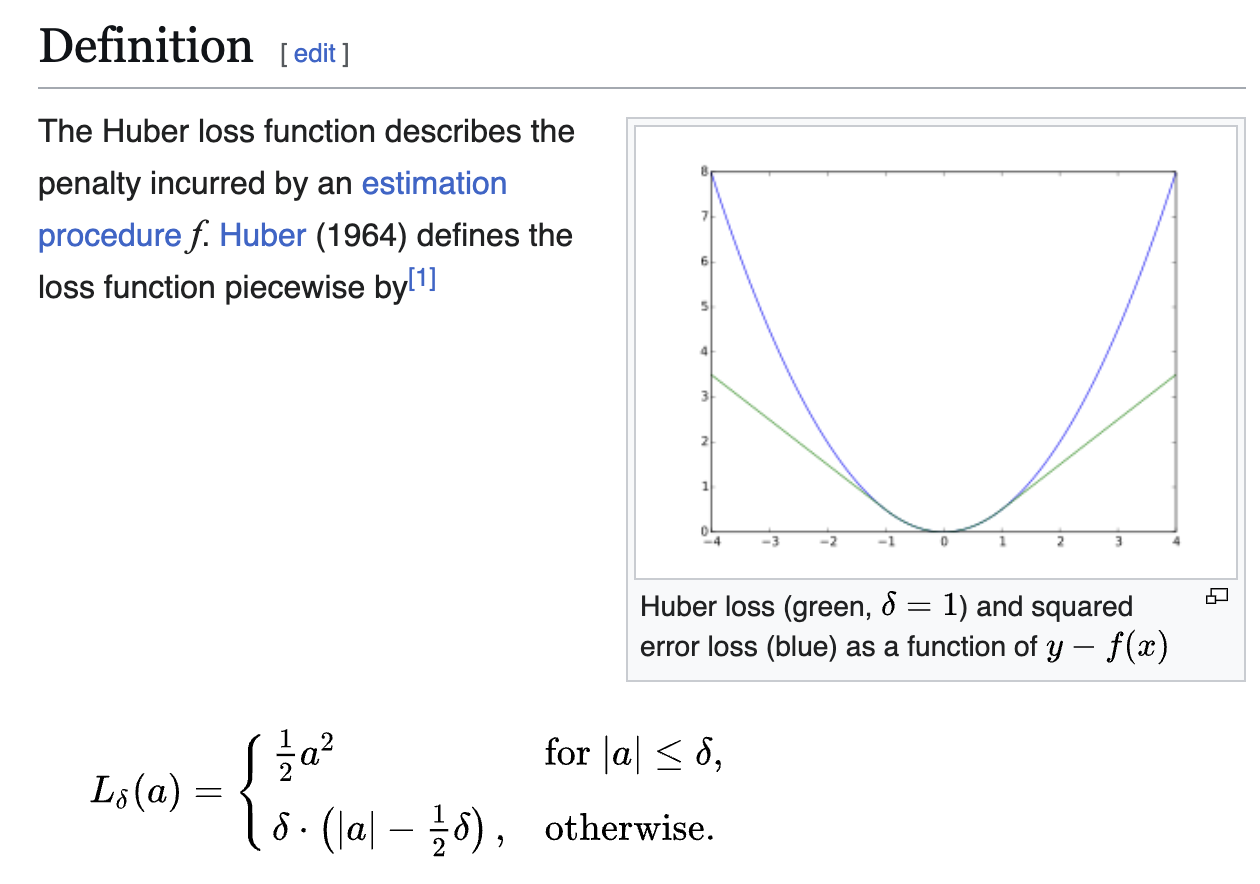

In [15]:
data = pd.read_csv("imports-85.data", header=None, na_values="?")
data.head()

data.loc[:, data.dtypes == "float64"] = data.loc[:, data.dtypes == "float64"].fillna(
    data.loc[:, data.dtypes == "float64"].mean(axis=0)
)
data.loc[:, data.dtypes == "object"] = data.loc[:, data.dtypes == "object"].fillna("")
data.head()

data_encoded = pd.get_dummies(data)
data_encoded

data_encoded.columns = data_encoded.columns.astype(str)
X = data_encoded.drop(columns=["25"])
y = data_encoded["25"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=3)

scaler = RobustScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

#### Код семинара

In [48]:
class MyLinearRegression:
    def __init__(self, lr=0.001, num_iter=10000) -> None:
        self.lr = lr
        self.num_iter = num_iter

    def calculate_loss(self, y, y_pred):
        return ((y - y_pred) ** 2).mean()

    def calculate_dldw(self, y, y_pred, x):
        grad_w = (-2 * (x.T * (y - y_pred)).T).mean(axis=0)
        return grad_w

    def calculate_dldb(self, y, y_pred):
        grad_b = (-2 * (y - y_pred)).mean()
        return grad_b

    def fit(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        self.weights = np.random.rand(X_train.shape[1])
        self.b = 0
        for i in range(self.num_iter):
            pred = (X_train @ self.weights) + self.b
            self.weights -= self.lr * self.calculate_dldw(y_train, pred, X_train)
            self.b -= self.lr * self.calculate_dldb(y_train, pred)

    def predict(self, X_test):
        return X_test @ self.weights + self.b

In [49]:
my_model = MyLinearRegression()
my_model.fit(X_train, y_train)
preds = my_model.predict(X_test)
print(f"""
    MSE_test = {metrics.mean_squared_error(preds, y_test)},
    MAE_test = {metrics.mean_absolute_error(preds, y_test)}
    r2_test = {metrics.r2_score(y_test, preds)}"""
)


    MSE_test = 3083466.7369018965,
    MAE_test = 1449.9492403565473
    r2_test = 0.9611393441955041


#### Домашняя реализация

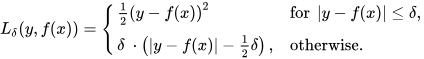

In [65]:
class MyHuberLinearRegression:
    def __init__(self, lr=0.5, num_iter=20000, sigma=1.3) -> None:
        self.lr = lr
        self.num_iter = num_iter
        self.sigma = sigma

    def calculate_loss(self, y, y_pred):
        a = np.abs(y - y_pred)
        return np.where(a <= self.sigma, 0.5 * a**2, self.sigma * (a - 0.5 * self.sigma)).mean()
    
    def calculate_dldw(self, y, y_pred, x):
        r = y - y_pred
        return  -(x.T @ np.where(np.abs(r) <= self.sigma, r, self.sigma * np.sign(r))) / len(y)

    def calculate_dldb(self, y, y_pred):
        r = y - y_pred
        return -np.where(np.abs(r) <= self.sigma, r, self.sigma * np.sign(r)).mean()

    def fit(self, X_train, y_train):
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        self.weights = np.random.rand(X_train.shape[1])
        self.b = 0
        for i in range(self.num_iter):
            pred = (X_train @ self.weights) + self.b
            self.weights -= self.lr * self.calculate_dldw(y_train, pred, X_train)
            self.b -= self.lr * self.calculate_dldb(y_train, pred)

    def predict(self, X_test):
        return X_test @ self.weights + self.b

In [66]:
my_model = MyHuberLinearRegression()
my_model.fit(X_train, y_train)
preds = my_model.predict(X_test)
print(f"""
    MSE_test = {metrics.mean_squared_error(preds, y_test)},
    MAE_test = {metrics.mean_absolute_error(preds, y_test)}
    r2_test = {metrics.r2_score(y_test, preds)}"""
)


    MSE_test = 8102074.980658252,
    MAE_test = 2157.3835688411527
    r2_test = 0.8978902728680236


Подберем гипперпараметры

In [72]:
best_r2 = -100000
best_params = None

for lr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    for num_iter in [1000, 3000, 5000, 10000, 20000, 30000, 50000, 100000]:
        for sigma in [0.5, 0.8, 1.0, 1.3, 1.5, 2.0, 3.0]:
            model = MyHuberLinearRegression(lr=lr, num_iter=num_iter, sigma=sigma)
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            r2 = metrics.r2_score(y_test, preds)
            
            print(f"lr={lr:.1f}, iter={num_iter}, sigma={sigma} -> R²={r2:.4f}")
        
            if r2 > best_r2:
                best_r2 = r2
                best_params = (lr, num_iter, sigma)

lr=0.1, iter=1000, sigma=0.5 -> R²=-1.8825
lr=0.1, iter=1000, sigma=0.8 -> R²=-1.8325
lr=0.1, iter=1000, sigma=1.0 -> R²=-1.8002
lr=0.1, iter=1000, sigma=1.3 -> R²=-1.7521
lr=0.1, iter=1000, sigma=1.5 -> R²=-1.7203
lr=0.1, iter=1000, sigma=2.0 -> R²=-1.6427
lr=0.1, iter=1000, sigma=3.0 -> R²=-1.4930
lr=0.1, iter=3000, sigma=0.5 -> R²=-1.7207
lr=0.1, iter=3000, sigma=0.8 -> R²=-1.5820
lr=0.1, iter=3000, sigma=1.0 -> R²=-1.4929
lr=0.1, iter=3000, sigma=1.3 -> R²=-1.3757
lr=0.1, iter=3000, sigma=1.5 -> R²=-1.3098
lr=0.1, iter=3000, sigma=2.0 -> R²=-1.1548
lr=0.1, iter=3000, sigma=3.0 -> R²=-0.8928
lr=0.1, iter=5000, sigma=0.5 -> R²=-1.5669
lr=0.1, iter=5000, sigma=0.8 -> R²=-1.3646
lr=0.1, iter=5000, sigma=1.0 -> R²=-1.2554
lr=0.1, iter=5000, sigma=1.3 -> R²=-1.1060
lr=0.1, iter=5000, sigma=1.5 -> R²=-1.0172
lr=0.1, iter=5000, sigma=2.0 -> R²=-0.8122
lr=0.1, iter=5000, sigma=3.0 -> R²=-0.4511
lr=0.1, iter=10000, sigma=0.5 -> R²=-1.2556
lr=0.1, iter=10000, sigma=0.8 -> R²=-0.9752
lr=0.1, i

In [73]:
best_params

(0.9, 100000, 3.0)

R²=0.9761